# TC 5033
## Deep Learning
## Convolutional Neural Networks
<br>

#### Activity 2b: Building a CNN for CIFAR10 dataset with PyTorch
<br>

---

*   A01566204 - Natalia Nevarez Tinoco
*   A01746998 - Alexys Martín Coate Reyes
*   A01378966 - Erick Alberto Bustos Cruz
*   A01796998 - Miguel Angel Fernandez Castresana

---

- Objective

    The main goal of this activity is to further your understanding of Convolutional Neural Networks (CNNs) by building one using PyTorch. You will apply this architecture to the famous CIFAR10 dataset, taking what you've learned from the guide code that replicated the Fully Connected model in PyTorch (Activity 2a).

- Instructions
    This activity requires submission in teams of 5 or 6 members. Submissions from smaller or larger teams will not be accepted unless prior approval has been granted (only due to exceptional circumstances). While teamwork is encouraged, each member is expected to contribute individually to the assignment. The final submission should feature the best arguments and solutions from each team member. Only one person per team needs to submit the completed work, but it is imperative that the names of all team members are listed in a Markdown cell at the very beginning of the notebook (either the first or second cell). Failure to include all team member names will result in the grade being awarded solely to the individual who submitted the assignment, with zero points given to other team members (no exceptions will be made to this rule).

    Understand the Guide Code: Review the guide code from Activity 2a that implemented a Fully Connected model in PyTorch. Note how PyTorch makes it easier to implement neural networks.

    Familiarize Yourself with CNNs: Take some time to understand their architecture and the rationale behind using convolutional layers.

    Prepare the Dataset: Use PyTorch's DataLoader to manage the dataset. Make sure the data is appropriately preprocessed for a CNN.

    Design the CNN Architecture: Create a new architecture that incorporates convolutional layers. Use PyTorch modules like nn.Conv2d, nn.MaxPool2d, and others to build your network.

    Training Loop and Backpropagation: Implement the training loop, leveraging PyTorch’s autograd for backpropagation. Keep track of relevant performance metrics.

    Analyze and Document: Use Markdown cells to explain your architectural decisions, performance results, and any challenges you faced. Compare this model with your previous Fully Connected model in terms of performance and efficiency.

- Evaluation Criteria

    - Understanding of CNN architecture and its application to the CIFAR10 dataset
    - Code Readability and Comments
    - Appropriateness and efficiency of the chosen CNN architecture
    - Correct implementation of Traning Loop and Accuracy Function
    - Model's performance metrics on the CIFAR10 dataset (at least 65% accuracy)
    - Quality of Markdown documentation

- Submission

Submit via Canvas your Jupyter Notebook with the CNN implemented in PyTorch. Your submission should include well-commented code and Markdown cells that provide a comprehensive view of your design decisions, performance metrics, and learnings.

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch.utils.data import sampler
import torchvision.datasets as datasets
import torchvision.transforms as T
import matplotlib.pyplot as plt
import time
#only if you have jupyterthemes
#from jupyterthemes import jtplot
#jtplot.style()

In [2]:
# Team Reproducibility Configuration
'''
To ensure all team members get consistent results when running this notebook:

- Gloval seed: 42 (for NumPy, random, PyTorch CPU operations)
- Training seed: 123 (reserved for potential future use)
- Deterministic mode: Enabled for PyTorch CUDA operations
- Benchmark mode: Disabled to ensure reproducibility

Note: Training times may vary slightly across different hardware, but
accuracy metrics should be identical (±0.1% due to floating point precision)

'''

import sys

GLOBAL_SEED = 42
TRAIN_SEED = 123

# Set all random seeds
np.random.seed(GLOBAL_SEED)
import random
random.seed(GLOBAL_SEED)
torch.manual_seed(GLOBAL_SEED)
torch.cuda.manual_seed(GLOBAL_SEED)
torch.cuda.manual_seed_all(GLOBAL_SEED)  # For multi-GPU

# Configure PyTorch for reproducibility
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print(f"Global Seed: {GLOBAL_SEED}")
print(f"Training Seed: {TRAIN_SEED}")
print(f"NumPy version: {np.__version__}")
print(f"PyTorch version: {torch.__version__}")
print(f"Python version: {sys.version}")

Global Seed: 42
Training Seed: 123
NumPy version: 2.0.2
PyTorch version: 2.9.0+cpu
Python version: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]


### Download Cifar10 dataset

In [3]:
torch.cuda.is_available()

False

In [4]:
DATA_PATH = '/content/drive/MyDrive/Colab Notebooks/MNA/Advanced ML /Semana4'
NUM_TRAIN = 50000
NUM_VAL = 5000
NUM_TEST = 5000
MINIBATCH_SIZE = 64

transform_cifar = T.Compose([
                T.ToTensor(),
                T.Normalize([0.491, 0.482, 0.447], [0.247, 0.243, 0.261])
            ])

# Train dataset
cifar10_train = datasets.CIFAR10(DATA_PATH, train=True, download=True,
                             transform=transform_cifar)
train_loader = DataLoader(cifar10_train, batch_size=MINIBATCH_SIZE,
                          sampler=sampler.SubsetRandomSampler(range(NUM_TRAIN)))
#Validation set
cifar10_val = datasets.CIFAR10(DATA_PATH, train=False, download=True,
                           transform=transform_cifar)
val_loader = DataLoader(cifar10_val, batch_size=MINIBATCH_SIZE,
                        sampler=sampler.SubsetRandomSampler(range(NUM_VAL)))
#Test set
cifar10_test = datasets.CIFAR10(DATA_PATH, train=False, download=True,
                            transform=transform_cifar)
test_loader = DataLoader(cifar10_test, batch_size=MINIBATCH_SIZE,
                        sampler=sampler.SubsetRandomSampler(range(NUM_VAL, len(cifar10_test))))

100%|██████████| 170M/170M [00:01<00:00, 92.1MB/s]


In [5]:
print(f"Training samples: {NUM_TRAIN}")
print(f"Validation samples: {NUM_VAL}")
print(f"Test samples: {len(cifar10_test) - NUM_VAL}")
print(f"Batch size: {MINIBATCH_SIZE}")

Training samples: 50000
Validation samples: 5000
Test samples: 5000
Batch size: 64


In [6]:
cifar10_train

Dataset CIFAR10
    Number of datapoints: 50000
    Root location: /content/drive/MyDrive/Colab Notebooks/MNA/Advanced ML /Semana4
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=[0.491, 0.482, 0.447], std=[0.247, 0.243, 0.261])
           )

In [7]:
test_loader.dataset

Dataset CIFAR10
    Number of datapoints: 10000
    Root location: /content/drive/MyDrive/Colab Notebooks/MNA/Advanced ML /Semana4
    Split: Test
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=[0.491, 0.482, 0.447], std=[0.247, 0.243, 0.261])
           )

In [8]:
train_loader.batch_size

64

In [9]:
for i, (x, y) in enumerate(train_loader):
    print(x, y)

Streaming output truncated to the last 5000 lines.

         [[ 6.7636e-01,  7.0641e-01,  6.3128e-01,  ...,  9.7686e-01,
            8.5666e-01,  7.2143e-01],
          [ 8.4163e-01,  8.4163e-01,  7.0641e-01,  ...,  8.5666e-01,
            8.2661e-01,  7.3646e-01],
          [ 7.8153e-01,  7.9656e-01,  7.3646e-01,  ...,  9.0174e-01,
            9.0174e-01,  8.4163e-01],
          ...,
          [ 9.7686e-01,  9.7686e-01,  1.0069e+00,  ...,  1.6079e+00,
            1.5929e+00,  1.5478e+00],
          [ 5.4113e-01,  8.7169e-01,  1.0370e+00,  ...,  1.5929e+00,
            1.5478e+00,  1.4577e+00],
          [ 6.4631e-01,  9.3179e-01,  9.6184e-01,  ...,  1.6680e+00,
            1.5478e+00,  1.3976e+00]]]]) tensor([2, 8, 1, 6, 2, 5, 2, 0, 6, 8, 0, 3, 5, 0, 3, 2, 2, 9, 4, 5, 6, 9, 2, 9,
        9, 9, 1, 4, 1, 5, 1, 8, 1, 5, 6, 1, 1, 1, 0, 1, 5, 7, 6, 2, 3, 9, 2, 0,
        2, 3, 6, 7, 7, 7, 5, 9, 7, 3, 6, 4, 5, 3, 4, 3])
tensor([[[[-1.0035e+00, -1.0511e+00, -1.0511e+00,  ..., -9.7174e-01,
  

### Using  GPUs

In [10]:
if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')
print(device)

cpu


### Mostrar imágenes

La imagen muestreada representa un: ship


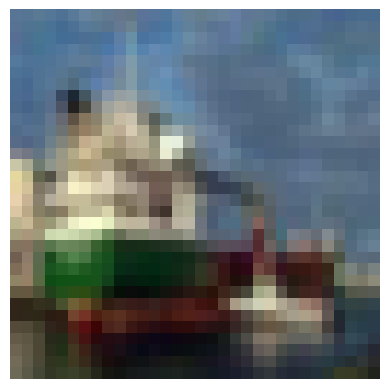

In [11]:
classes = test_loader.dataset.classes
def plot_figure(image):
    plt.imshow(np.transpose(image,(1,2,0)))
    plt.axis('off')
    plt.show()

rnd_sample_idx = np.random.randint(len(test_loader))
print(f'La imagen muestreada representa un: {classes[test_loader.dataset[rnd_sample_idx][1]]}')
image = test_loader.dataset[rnd_sample_idx][0]
image = (image - image.min()) / (image.max() -image.min() )
plot_figure(image)


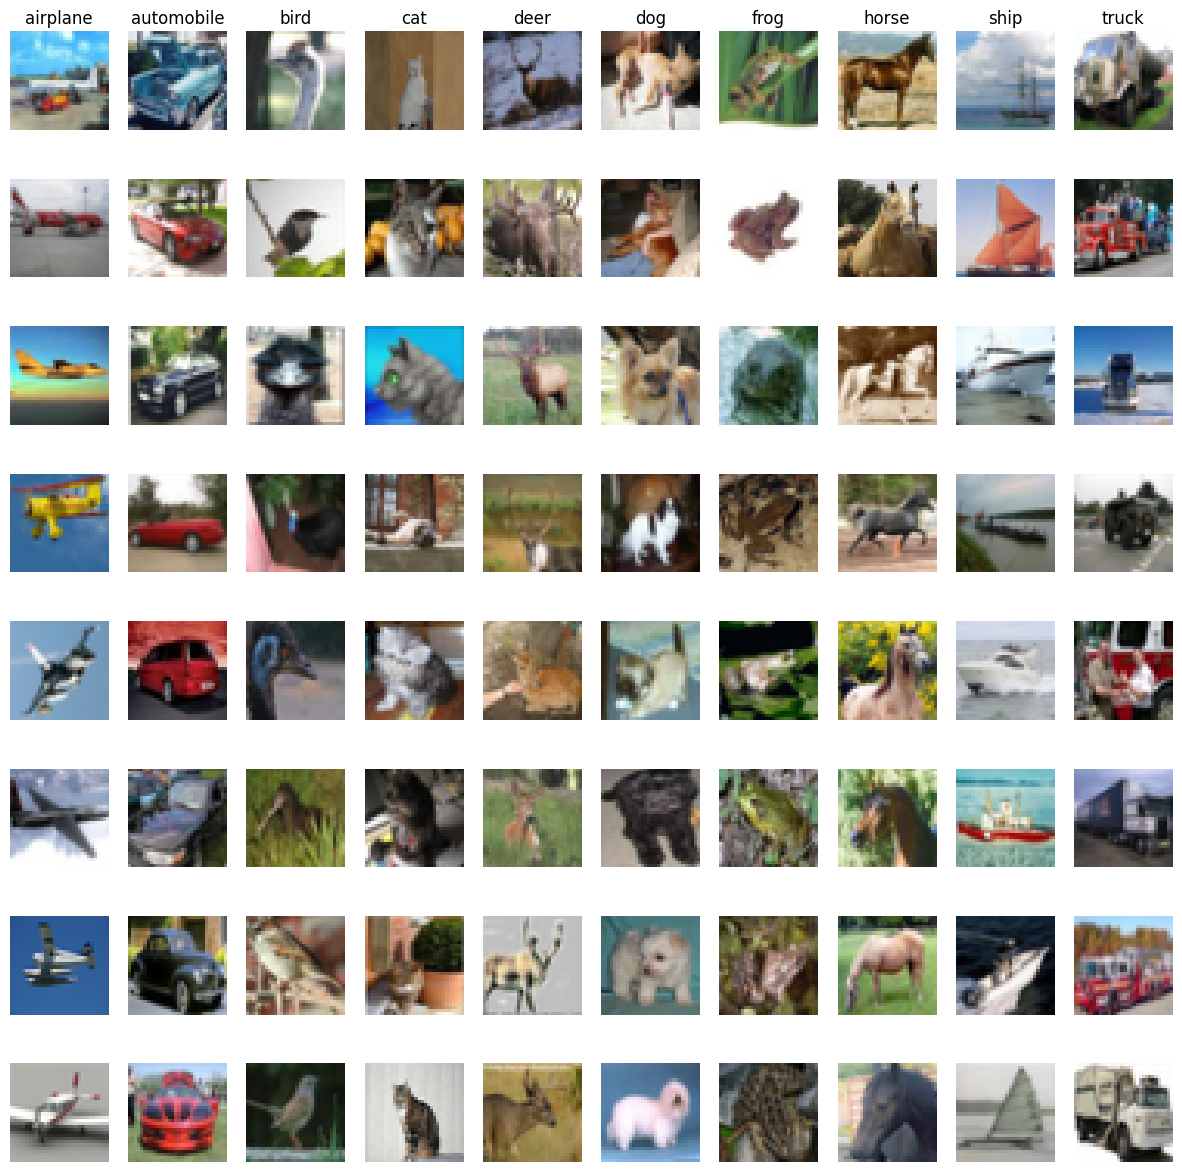

In [12]:
def plot_cifar10_grid():
    classes = test_loader.dataset.classes
    total_samples = 8
    plt.figure(figsize=(15,15))
    for label, sample in enumerate(classes):
        class_idxs = np.flatnonzero(label == np.array(test_loader.dataset.targets))
        sample_idxs = np.random.choice(class_idxs, total_samples, replace = False)
        for i, idx in enumerate(sample_idxs):
            plt_idx = i*len(classes) + label + 1
            plt.subplot(total_samples, len(classes), plt_idx)
            plt.imshow(test_loader.dataset.data[idx])
            plt.axis('off')

            if i == 0: plt.title(sample)
    plt.show()

plot_cifar10_grid()

### Calcular accuracy


In [13]:
for i, (x,y) in enumerate(test_loader):
  print(i, x.shape, y.shape)

0 torch.Size([64, 3, 32, 32]) torch.Size([64])
1 torch.Size([64, 3, 32, 32]) torch.Size([64])
2 torch.Size([64, 3, 32, 32]) torch.Size([64])
3 torch.Size([64, 3, 32, 32]) torch.Size([64])
4 torch.Size([64, 3, 32, 32]) torch.Size([64])
5 torch.Size([64, 3, 32, 32]) torch.Size([64])
6 torch.Size([64, 3, 32, 32]) torch.Size([64])
7 torch.Size([64, 3, 32, 32]) torch.Size([64])
8 torch.Size([64, 3, 32, 32]) torch.Size([64])
9 torch.Size([64, 3, 32, 32]) torch.Size([64])
10 torch.Size([64, 3, 32, 32]) torch.Size([64])
11 torch.Size([64, 3, 32, 32]) torch.Size([64])
12 torch.Size([64, 3, 32, 32]) torch.Size([64])
13 torch.Size([64, 3, 32, 32]) torch.Size([64])
14 torch.Size([64, 3, 32, 32]) torch.Size([64])
15 torch.Size([64, 3, 32, 32]) torch.Size([64])
16 torch.Size([64, 3, 32, 32]) torch.Size([64])
17 torch.Size([64, 3, 32, 32]) torch.Size([64])
18 torch.Size([64, 3, 32, 32]) torch.Size([64])
19 torch.Size([64, 3, 32, 32]) torch.Size([64])
20 torch.Size([64, 3, 32, 32]) torch.Size([64])
21

In [14]:
def accuracy(model, loader):
  '''
  Calculate the accuracy of the model on the provided data loader.

  Args:
    model: Neural network model
    loader: DataLoader containing the dataset

  Returns:
    accuracy: Percentage of correctly classified samples
  '''
  model.eval() # Set model to evaluation mode
  model = model.to(device=device)
  num_correct = 0
  num_total = 0

  with torch.no_grad():
    for xi, yi in loader:
      # Move data to device
      xi = xi.to(device=device, dtype = torch.float32)
      yi = yi.to(device=device, dtype=torch.long)

      # Forward pass
      scores = model(xi)

      # Get predictions
      _, pred = scores.max(dim=1)

      # Update counters
      num_correct += (pred == yi).sum().item()
      num_total += pred.size(0)


    # Calculate accuracy as percentage
    acc = 100 * num_correct/num_total
    return acc

### Loop de entrenamiento

In [15]:
def train(model, optimiser, epochs=100, patience=None, min_delta=1e-4, print_every=2):
  '''
  Train the nerural network model

  Args:
    model: Neural network to train
    optimiser: PyTorch optimizer (e.g. Adam, SGD)
    epochs: Number of training epochs
    patience: Epochs to wait before early stopping (None = disabled)
    min_delta = Minimum improvement for early stopping
    print_every = Print statistics every N epochs

  Returns:
    history: Dictionary containing training history
  '''
  # Move model to device
  model = model.to(device=device)

  # Loss function
  criterion = nn.CrossEntropyLoss()

  # History tracking
  train_losses = []
  train_accs = []
  val_accs = []

  # Early stopping setup
  best_val_acc = -np.inf
  best_model_state = None
  epochs_no_improve = 0

  print('Starting training...')
  print(f'Device: {device}')
  print(f'Epochs: {epochs}')
  print(f'Early stopping: {'Enabled' if patience else 'Disabled'}')

  for epoch in range(epochs):
    # Training phase
    model.train()
    epoch_loss = 0.0 # track total loss

    for i, (xi, yi) in enumerate(train_loader):
      # Move data to device
      xi = xi.to(device=device, dtype=torch.float32)
      yi = yi.to(device=device, dtype=torch.long)

      # Zero gradients
      optimiser.zero_grad()

      # Forward pass
      scores = model(xi)
      loss = criterion(scores, yi)

      # Backward pass
      loss.backward()

      # Update weights
      optimiser.step()

      # Accumulate loss
      epoch_loss += loss.item()

    # METRICS CALCULATION
    # Calculate average loss for this epoch
    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)

    # Calculate accuracies every print_every epochs
    if (epoch + 1) % print_every == 0 or epoch == epochs - 1:
      train_acc = accuracy(model, train_loader)
      val_acc = accuracy(model, val_loader)
      train_accs.append(train_acc)
      val_accs.append(val_acc)

      print(f"Epoch [{epoch+1:3d}/{epochs}] | "
                  f"Loss: {avg_loss:.4f} | "
                  f"Train Acc: {train_acc:.2f}% | "
                  f"Val Acc: {val_acc:.2f}%")

      # Early Stopping
      if patience is not None:
        # Check if validation accuracy improved
        if val_acc > best_val_acc + min_delta:
          best_val_acc = val_acc
          epochs_no_improve = 0
          # Save best model weights
          best_model_state = {
              'epoch': epoch + 1,
              'model_state_dict': model.state_dict(),
              'optimizer_state_dict': optimiser.state_dict(),
              'val_acc': val_acc,
              'train_acc': avg_loss
          }
          print(f'  → New best! Val Acc: {best_val_acc:.2f}%')
        else:
          epochs_no_improve += 1
          print(f"  → No improvement ({epochs_no_improve}/{patience})")

          # Early stopping triggered
          if epochs_no_improve >= patience:
            print(f"Early stopping triggered at epoch {epoch + 1}")
            print(f"Best validation accuracy: {best_val_acc:.2f}%")

            # Restore best weights
            if best_model_state is not None:
              model.load_state_dict(best_model_state['model_state_dict'])
              print(f"Restored model from epoch {best_model_state['epoch']}")
            break

  # If early stopping was enabled but didn't trigger, still save best model
  if patience is not None and best_model_state is not None and epochs_no_improve < patience:
    model.load_state_dict(best_model_state['model_state_dict'])
    print(f"Loaded best model from epoch {best_model_state['epoch']} (val_acc: {best_val_acc:.2f}%)")

  # Return training history
  history = {
      'train_losses': train_losses,
      'train_accs': train_accs,
      'val_accs': val_accs,
      'best_val_acc': best_val_acc if patience else val_accs[-1] if val_accs else None,
      'best_model_state': best_model_state
  }
  return history

### Linear model

### Arcgutecture Design

We start with a simple baseline model using only fully connected layers. This will help us understand the imrpovement that convolutional layers bring.

**Architecture**:

- Input: 32x32x3 = 3,072 features (flattened RGB image)
- Hidden Layer 1: 512 neurons + ReLU activation
- Hidden Layer 2: 256 neurons + ReLU activation
- Output: 10 neurons (one for each class)

**Why this architecture?**

- Two hidden layers provide enough capacity to learn patterns
- ReLU activation helps with training speed and avoids vanishing gradients
- Progressively decreasing layer sizes (3072 → 512 → 256 → 10) create a funnel effect

In [16]:
# To do: Use PyTorch to create a linear model to have an initial baseline model

In [17]:
class LinearModel(nn.Module):
  '''
  Baseline fully connected neural network
  Flattens the input image and passes through dense layers
  '''
  def __init__(self):
    super(LinearModel, self).__init__()
    # Input: 32x32x2 = 3072 features
    self.fc1 = nn.Linear(3*32*32, 512)
    self.fc2 = nn.Linear(512, 256)
    self.fc3 = nn.Linear(256, 10) # 10 output classes

  def forward(self, x):
    # Flatten the image: [batch_size, 3, 32, 32] -> [batch_size, 3072]
    x = x.view(x.size(0), -1)

    # Layer 1: Linear + ReLU
    x = F.relu(self.fc1(x))

    # Layer 2: Linear + ReLU
    x = F.relu(self.fc2(x))

    # Output Layer (no activations - handled by CrossEntropyLoss)
    x = self.fc3(x)

    return x

# Create the model
model_linear = LinearModel()

# Count Parameters
total_params = sum(p.numel() for p in model_linear.parameters())
print(f"Linear model - Total parameters: {total_params:,}")
print('\nModel Architecture:')
print(model_linear)

Linear model - Total parameters: 1,707,274

Model Architecture:
LinearModel(
  (fc1): Linear(in_features=3072, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=256, bias=True)
  (fc3): Linear(in_features=256, out_features=10, bias=True)
)


In [18]:
# Define optimizer (Adam with learning rate of 0.001)
optimiser = torch.optim.Adam(model_linear.parameters(), lr=0.001)
epochs = 20

In [19]:
# Start time
start_time = time.time()

history_linear = train(model_linear, optimiser, epochs=epochs, patience=None, print_every=2)

# End timing
end_time = time.time()
training_time_linear = end_time - start_time
print(f'Linear Model Training Time: {training_time_linear:.2f} seconds ({training_time_linear/60:.2f} minutes)')

Starting training...
Device: cpu
Epochs: 20
Early stopping: Disabled
Epoch [  2/20] | Loss: 1.4614 | Train Acc: 53.04% | Val Acc: 48.90%
Epoch [  4/20] | Loss: 1.2808 | Train Acc: 58.44% | Val Acc: 52.48%
Epoch [  6/20] | Loss: 1.1455 | Train Acc: 63.54% | Val Acc: 53.14%
Epoch [  8/20] | Loss: 1.0213 | Train Acc: 66.87% | Val Acc: 53.78%
Epoch [ 10/20] | Loss: 0.9019 | Train Acc: 71.29% | Val Acc: 53.10%
Epoch [ 12/20] | Loss: 0.8174 | Train Acc: 73.67% | Val Acc: 52.80%
Epoch [ 14/20] | Loss: 0.7244 | Train Acc: 76.73% | Val Acc: 52.96%
Epoch [ 16/20] | Loss: 0.6474 | Train Acc: 78.67% | Val Acc: 52.20%
Epoch [ 18/20] | Loss: 0.5956 | Train Acc: 80.34% | Val Acc: 52.44%
Epoch [ 20/20] | Loss: 0.5406 | Train Acc: 83.92% | Val Acc: 52.40%
Linear Model Training Time: 924.64 seconds (15.41 minutes)


In [20]:
test_acc_linear = accuracy(model_linear, test_loader)
print(f"Linear Model - Test Accuracy: {test_acc_linear:.2f}%")

Linear Model - Test Accuracy: 52.12%


### Sequential CNN

### Architecture Design

Now we build a Convolutional Neural Network that can better capture spatial figures in images.

**Architecture**

1. Convolutional Block 1:
   - Conv2d: 3 → 32 channels, 3x3 kernel, padding=1
   - ReLU activation
   - BatchNorm2d: 32 channels
   - Conv2d: 32 → 32 channels, 3x3 kernel, padding=1
   - ReLU activation
   - BatchNorm2d: 32 channels
   - MaxPool2d: 2x2 (reduces spatial dimensions by half)
   - Output: 32 × 16 × 16

2. **Convolutional Block 2:**
   - Conv2d: 32 → 64 channels, 3x3 kernel, padding=1
   - ReLU activation
   - BatchNorm2d: 64 channels
   - Conv2d: 64 → 64 channels, 3x3 kernel, padding=1
   - ReLU activation
   - BatchNorm2d: 64 channels
   - MaxPool2d: 2x2
   - Output: 64 × 8 × 8

3. **Convolutional Block 3:**
   - Conv2d: 64 → 128 channels, 3x3 kernel, padding=1
   - ReLU activation
   - BatchNorm2d: 128 channels
   - Conv2d: 128 → 128 channels, 3x3 kernel, padding=1
   - ReLU activation
   - BatchNorm2d: 128 channels
   - MaxPool2d: 2x2
   - Output: 128 × 4 × 4

4. **Fully Connected Layers:**
   - Flatten: 128 × 4 × 4 = 2048 features
   - FC1: 2048 → 512
   - ReLU activation
   - BatchNorm1d: 512 features
   - Dropout: 0.5
   - FC2: 512 → 10 (output classes)

**Design Rationale:**
- Multiple conv layers per block: Allows the network to learn more complex features
- Increasing channels (32 → 64 → 128): Learns progressively more abstract features
- Padding=1: Preserves spatial dimensions within each block
- MaxPooling: Reduces spatial dimensions and adds translation invariance
- Batch Normalization: Normalizes activations after ReLU, leading to:
  - Faster training convergence
  - More stable gradients during backpropagation
  - Allows higher learning rates
  - Acts as additional regularization
  - Reduces internal covariate shift
- Dropout (0.5): Prevents overfitting by randomly dropping 50% of neurons during training
- Small kernels (3x3): Efficient and captures local patterns well

**Layer Flow Pattern:**
- Convolutional blocks: `Conv2d → ReLU → BatchNorm2d`
- Fully connected: `Linear → ReLU → BatchNorm1d → Dropout → Linear`

In [21]:
# To do: Use PyTorch to implement a CNN model, accuracy should be better than
#the linear model

In [22]:
class CNN_class1(nn.Module):
  def __init__(self, in_channel, channel1, channel2, channel3):
    super().__init__()
    # Block 1
    self.conv1 = nn.Conv2d(in_channels=in_channel, out_channels =channel1,
                           kernel_size=3, padding=1)
    self.bn1 = nn.BatchNorm2d(channel1)
    self.conv2 = nn.Conv2d(in_channels=channel1, out_channels=channel1,
                           kernel_size=3, padding=1)
    self.bn2 = nn.BatchNorm2d(channel1)
    self.pool1 = nn.MaxPool2d(2,2) # 32x32 -> 16x16

    #Block 2
    self.conv3 = nn.Conv2d(in_channels=channel1, out_channels=channel2,
                           kernel_size=3, padding=1)
    self.bn3 = nn.BatchNorm2d(channel2)
    self.conv4 = nn.Conv2d(in_channels=channel2, out_channels=channel2,
                           kernel_size=3, padding=1)
    self.bn4 = nn.BatchNorm2d(channel2)
    self.pool2 = nn.MaxPool2d(2,2) #16x15 -> 8x8

    # Block 3
    self.conv5 = nn.Conv2d(in_channels=channel2, out_channels=channel3,
                           kernel_size=3, padding=1)
    self.bn5 = nn.BatchNorm2d(channel3)
    self.conv6 = nn.Conv2d(in_channels=channel3, out_channels=channel3,
                           kernel_size=3, padding=1)
    self.bn6 = nn.BatchNorm2d(channel3)
    self.pool3 = nn.MaxPool2d(2,2) # 8x8 -> 4x4

    self.flatten = nn.Flatten()
    self.fc1 = nn.Linear(in_features=4*4*channel3, out_features=512)
    self.bn_fc = nn.BatchNorm1d(512) # 1d for fully connected
    self.dropout = nn.Dropout(0.5)
    self.fc2 = nn.Linear(in_features=512, out_features=10)

  def forward(self, x):
    # Block 1
    x = self.bn1(F.relu(self.conv1(x))) # BN after activation
    x = self.bn2(F.relu(self.conv2(x))) # BN after activation
    x = self.pool1(x)

    #Block 2
    x = self.bn3(F.relu(self.conv3(x)))
    x = self.bn4(F.relu(self.conv4(x)))
    x = self.pool2(x)

    # Block 3
    x = self.bn5(F.relu(self.conv5(x)))
    x = self.bn6(F.relu(self.conv6(x)))
    x = self.pool3(x)

    # FC layers
    x = self.flatten(x)
    x = self.bn_fc(F.relu(self.fc1(x))) # BN after activation
    x = self.dropout(x)
    return self.fc2(x)

In [23]:
channel1 = 32
channel2 = 64
channel3 = 128
epochs = 20
lr = 0.001
modelCNN1 = CNN_class1(3, channel1, channel2, channel3)
optimiser = torch.optim.Adam(modelCNN1.parameters(), lr)

In [24]:
# Count parameters
total_params_cnn = sum(p.numel() for p in modelCNN1.parameters())
print(f'CNN Model - Total parameters: {total_params_cnn:,}')
print('\nModel Architecture:')
print(modelCNN1)

CNN Model - Total parameters: 1,343,146

Model Architecture:
CNN_class1(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn5): Batch

In [25]:
# start timimg
start_time_cnn = time.time()

history_cnn = train(modelCNN1, optimiser, epochs=epochs, patience=4, min_delta=0.1, print_every=2)

# end timing
end_time_cnn = time.time()
training_time_cnn = end_time_cnn - start_time_cnn
print(f'CNN Model Training Time: {training_time_cnn:.2f} seconds ({training_time_cnn/60:.2f} minutes)')

Starting training...
Device: cpu
Epochs: 20
Early stopping: Enabled
Epoch [  2/20] | Loss: 0.8086 | Train Acc: 79.54% | Val Acc: 76.40%
  → New best! Val Acc: 76.40%
Epoch [  4/20] | Loss: 0.5227 | Train Acc: 87.14% | Val Acc: 80.68%
  → New best! Val Acc: 80.68%
Epoch [  6/20] | Loss: 0.3622 | Train Acc: 93.40% | Val Acc: 82.46%
  → New best! Val Acc: 82.46%
Epoch [  8/20] | Loss: 0.2519 | Train Acc: 95.22% | Val Acc: 82.78%
  → New best! Val Acc: 82.78%
Epoch [ 10/20] | Loss: 0.1713 | Train Acc: 97.16% | Val Acc: 82.34%
  → No improvement (1/4)
Epoch [ 12/20] | Loss: 0.1241 | Train Acc: 98.44% | Val Acc: 82.72%
  → No improvement (2/4)
Epoch [ 14/20] | Loss: 0.1008 | Train Acc: 98.45% | Val Acc: 82.74%
  → No improvement (3/4)
Epoch [ 16/20] | Loss: 0.0718 | Train Acc: 99.00% | Val Acc: 83.40%
  → New best! Val Acc: 83.40%
Epoch [ 18/20] | Loss: 0.0782 | Train Acc: 99.07% | Val Acc: 83.44%
  → No improvement (1/4)
Epoch [ 20/20] | Loss: 0.0728 | Train Acc: 99.26% | Val Acc: 83.50%
  

In [26]:
test_acc_cnn = accuracy(modelCNN1, test_loader)
print(f"CNN Model - Test Accuracy: {test_acc_cnn:.2f}%")

CNN Model - Test Accuracy: 83.12%


## Misclassifcation Analysis

In [27]:
import itertools
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(model, loader, classes, normalize=False, title='Confusion Matrix'):
  '''
  Generate and plot confusion matrix

  Args:
    model: Trained model
    loader: DataLoader (typically test_loader)
    classes: Lost of class names
    normalize: Normalize confusion matrix
    title: Title of the plot
  '''
  model.eval()
  all_preds = []
  all_labels = []

  with torch.no_grad():
    for images, labels in loader:
      images = images.to(device)
      labels = labels.to(device)
      outputs = model(images)
      _, predicted = torch.max(outputs, 1)

      all_preds.extend(predicted.cpu().numpy())
      all_labels.extend(labels.cpu().numpy())

  # Compute confusion matrix
  cm = confusion_matrix(all_labels, all_preds)

  if normalize:
    cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

  # Plot
  plt.figure(figsize=(12, 10))
  plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
  plt.title(title, fontsize=16)
  plt.colorbar()

  tick_marks = np.arange(len(classes))
  plt.xticks(tick_marks, classes, rotation=45, ha='right')
  plt.yticks(tick_marks, classes)

  # Add text annotations
  fmt = '.2f' if normalize else 'd'
  thresh = cm.max() / 2.
  for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, format(cm[i, j], fmt),
             ha='center', va='center',
             color='white' if cm[i, j] > thresh else 'black',
             fontsize=10)

  plt.ylabel('True Label', fontsize=12)
  plt.xlabel('Predicted Label', fontsize=12)
  plt.tight_layout()
  plt.show()

  return cm

In [29]:
def analyze_per_class_accuracy(model, loader, classes):
  '''
  Calculate and display per-class accuracy with detailed statistics

  Args:
    model: Trained model
    loader: DataLoader
    classes: List of class names

  Returns:
    Dictionary with per-class statistics
  '''

  model.eval()
  class_correct = [0] * len(classes)
  class_total = [0] * len(classes)

  # Collect predictions
  with torch.no_grad():
    for images, labels in loader:
      images = images.to(device)
      labels = labels.to(device) # Corrected typo: 'lables' to 'labels'
      outputs = model(images)
      _, predicted = torch.max(outputs, 1)

      for i in range(labels.size(0)):
        label = labels[i].item()
        class_total[label] += 1
        if predicted[i] == labels[i]:
          class_correct[label] += 1

  # Calculate statistics
  results = []
  for i in range(len(classes)):
    acc = 100 * class_correct[i] / class_total[i] if class_total[i] > 0 else 0
    results.append({
        'class': classes[i],
        'accuracy': acc,
        'correct': class_correct[i],
        'total': class_total[i]
    })

  # Sort by accuracy
  results_sorted = sorted(results, key=lambda x: x['accuracy'])
  print("PER-CLASS ACCURACY ANALYSIS")
  print(f"{'Rank':<6} {'Class':<15} {'Accuracy':<12} {'Correct/Total':<15}")

  # Summary statistics
  accuracies = [r['accuracy'] for r in results]
  print(f"\nSummary Statistics:")
  print(f" • Best performing class:  {results_sorted[-1]['class']} ({results_sorted[-1]['accuracy']:.2f}%)")
  print(f" • Worst performing class: {results_sorted[0]['class']} ({results_sorted[0]['accuracy']:.2f}%)")
  print(f" • Average class accuracy: {np.mean(accuracies):.2f}%")
  print(f" • Std dev:                {np.std(accuracies):.2f}%")
  print(f" • Accuracy range:         {max(accuracies) - min(accuracies):.2f}%")

  return results_sorted # Return the sorted results for external use

In [30]:
def visualize_misclassifications(model, loader, classes, num_examples=20):
    """
    Visualize examples of misclassified images.

    Args:
        model: Trained model
        loader: DataLoader
        classes: List of class names
        num_examples: Number of misclassified examples to show
    """
    model.eval()
    misclassified = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            # Find misclassified images
            for i in range(labels.size(0)):
                if predicted[i] != labels[i]:
                    # Get prediction probabilities
                    probs = F.softmax(outputs[i], dim=0)
                    confidence = probs[predicted[i]].item()

                    misclassified.append({
                        'image': images[i].cpu(),
                        'true_label': labels[i].item(),
                        'pred_label': predicted[i].item(),
                        'confidence': confidence,
                        'top3_probs': torch.topk(probs, 3)
                    })

                    if len(misclassified) >= num_examples:
                        break

            if len(misclassified) >= num_examples:
                break

    # Sort by confidence (most confident mistakes first)
    misclassified.sort(key=lambda x: x['confidence'], reverse=True)

    # Plot
    fig, axes = plt.subplots(4, 5, figsize=(15, 12))
    axes = axes.ravel()

    for idx, item in enumerate(misclassified[:20]):
        # Denormalize image
        img = item['image'].numpy().transpose(1, 2, 0)
        img = (img - img.min()) / (img.max() - img.min())

        # Plot image
        axes[idx].imshow(img)
        axes[idx].axis('off')

        # Get top 3 predictions
        top3_values, top3_indices = item['top3_probs']

        # Title with true and predicted labels
        true_class = classes[item['true_label']]
        pred_class = classes[item['pred_label']]
        confidence = item['confidence'] * 100

        title = f"True: {true_class}\n"
        title += f"Pred: {pred_class} ({confidence:.1f}%)"

        axes[idx].set_title(title, fontsize=9, color='red')

    plt.suptitle('Most Confident Misclassifications', fontsize=16, y=1.00)
    plt.tight_layout()
    plt.show()

    # Print detailed analysis
    print("\n" + "="*70)
    print("MISCLASSIFICATION PATTERNS")
    print("="*70)

    # Count common confusions
    confusion_pairs = {}
    for item in misclassified:
        pair = (classes[item['true_label']], classes[item['pred_label']])
        confusion_pairs[pair] = confusion_pairs.get(pair, 0) + 1

    # Sort by frequency
    sorted_confusions = sorted(confusion_pairs.items(), key=lambda x: x[1], reverse=True)

    print("\nMost Common Confusions:")
    for (true_label, pred_label), count in sorted_confusions[:10]:
        print(f"  • {true_label} → {pred_label}: {count} times")


ANALYZING CNN MODEL MISCLASSIFICATIONS

Generating Confusion Matrix...


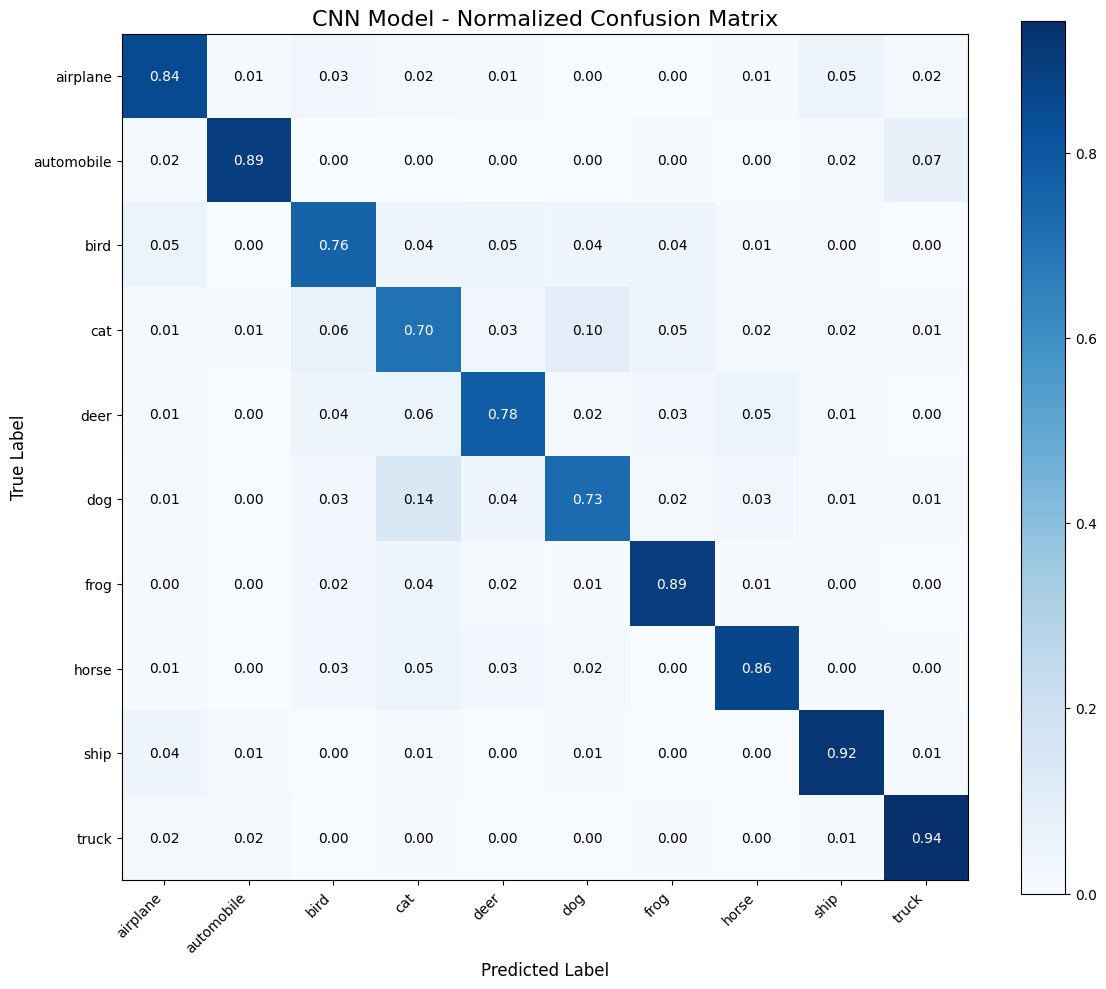


Per-Class Accuracy Analysis...
PER-CLASS ACCURACY ANALYSIS
Rank   Class           Accuracy     Correct/Total  

Summary Statistics:
 • Best performing class:  truck (94.25%)
 • Worst performing class: cat (70.38%)
 • Average class accuracy: 83.15%
 • Std dev:                7.98%
 • Accuracy range:         23.87%

Visualizing Misclassified Examples...


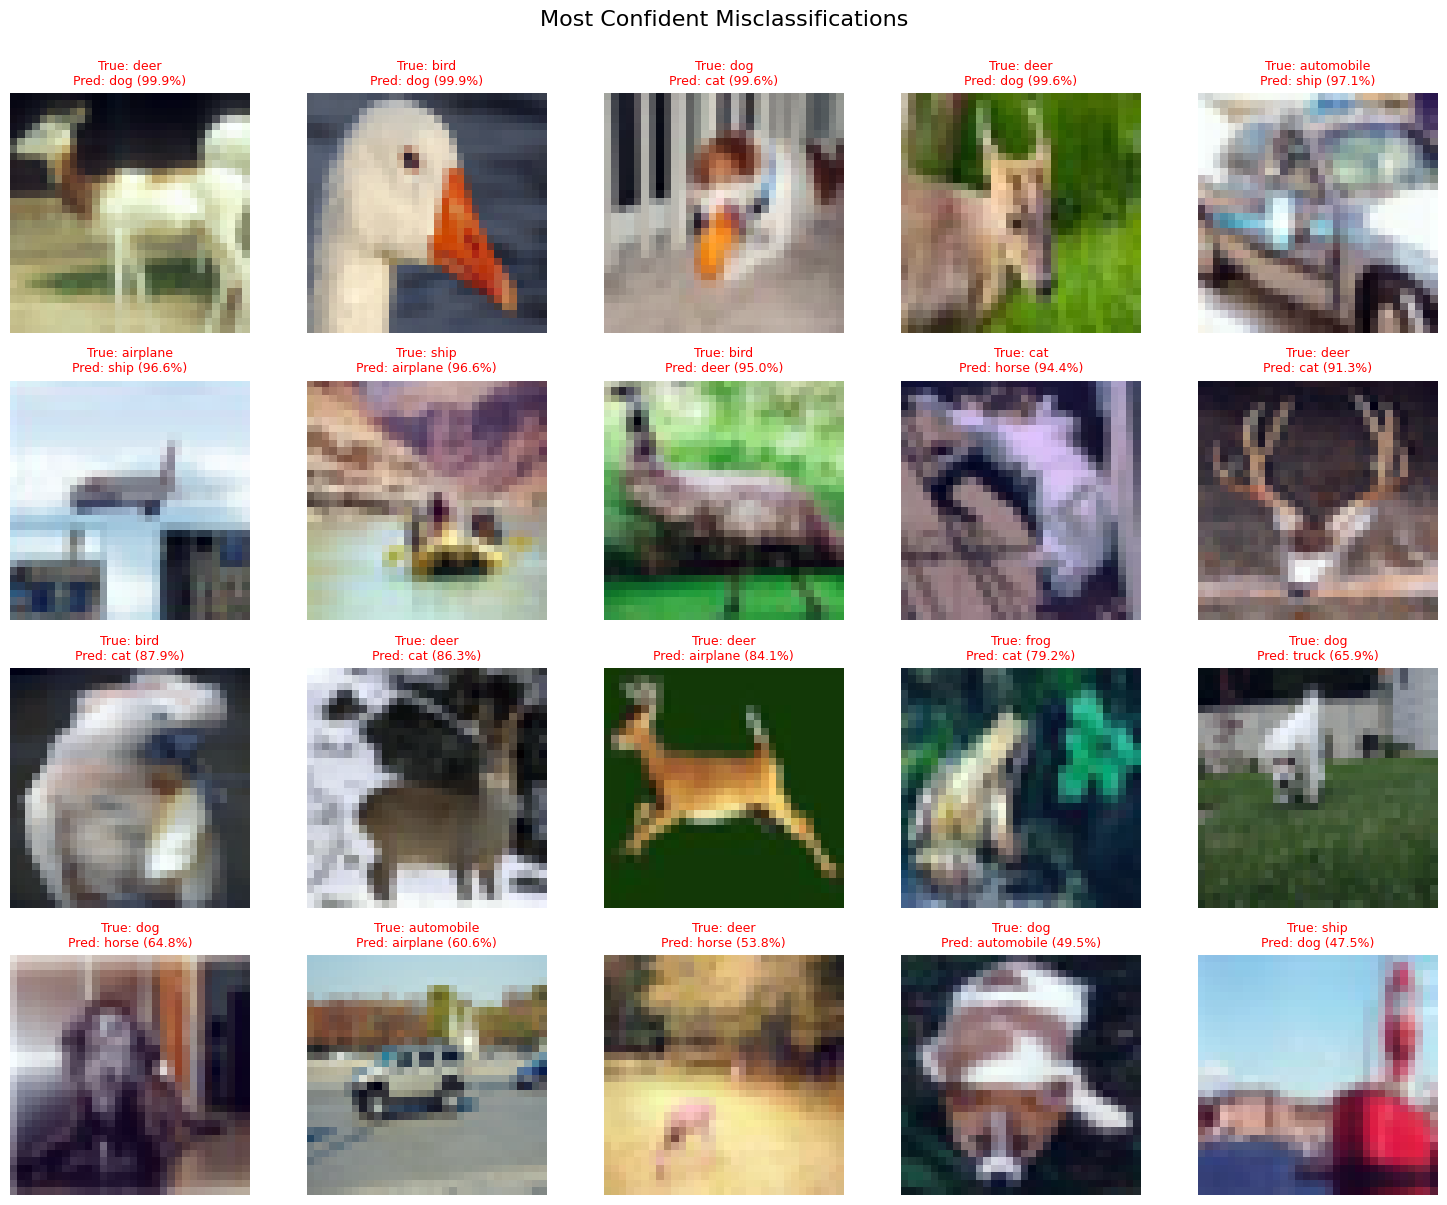


MISCLASSIFICATION PATTERNS

Most Common Confusions:
  • deer → dog: 2 times
  • deer → cat: 2 times
  • bird → dog: 1 times
  • dog → cat: 1 times
  • automobile → ship: 1 times
  • airplane → ship: 1 times
  • ship → airplane: 1 times
  • bird → deer: 1 times
  • cat → horse: 1 times
  • bird → cat: 1 times

KEY INSIGHTS AND RECOMMENDATIONS

Classes that need improvement:
  • cat: 70.38% accuracy
  • dog: 72.66% accuracy
  • bird: 75.82% accuracy


In [31]:
print("\n" + "="*70)
print("ANALYZING CNN MODEL MISCLASSIFICATIONS")
print("="*70)

# 1. Confusion Matrix
print("\nGenerating Confusion Matrix...")
classes = test_loader.dataset.classes
cm = plot_confusion_matrix(modelCNN1, test_loader, classes,
                           normalize=True,
                           title='CNN Model - Normalized Confusion Matrix')

# 2. Per-Class Accuracy
print("\nPer-Class Accuracy Analysis...")
class_results = analyze_per_class_accuracy(modelCNN1, test_loader, classes)

# 3. Visualize Misclassifications
print("\nVisualizing Misclassified Examples...")
visualize_misclassifications(modelCNN1, test_loader, classes, num_examples=20)

# 4. Analysis and Insights
print("\n" + "="*70)
print("KEY INSIGHTS AND RECOMMENDATIONS")
print("="*70)

# Identify problematic classes
worst_3 = class_results[:3]
print("\nClasses that need improvement:")
for r in worst_3:
    print(f"  • {r['class']}: {r['accuracy']:.2f}% accuracy")

## Performance Comparison and Analysis

We will compare the performance of our two models and visualize the training process

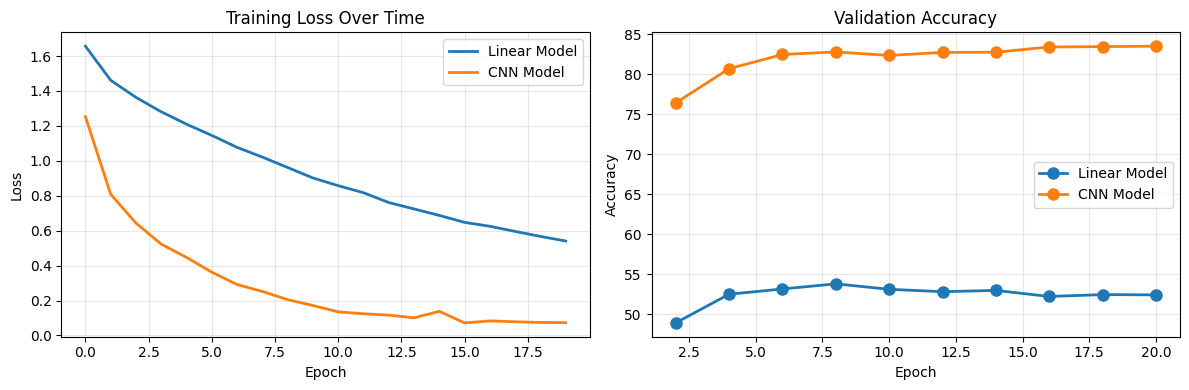

In [34]:
from IPython.terminal.embed import line_magic
# Plot training loss
plt.figure(figsize=(12,4))

plt.subplot(1, 2, 1)
plt.plot(history_linear['train_losses'], label='Linear Model', linewidth=2)
plt.plot(history_cnn['train_losses'], label='CNN Model', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Over Time')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
# The validation accuracies are recorded every 'print_every' epochs
# 'print_every' is 2 and 'epochs' is 20, so there are 10 validation accuracy points.
# We need to generate epochs_acc from 2 to 20, step 2.
epochs_acc = list(range(2, epochs + 1, 2))
plt.plot(epochs_acc, history_linear['val_accs'], 'o-', label='Linear Model', linewidth=2, markersize=8)
plt.plot(epochs_acc, history_cnn['val_accs'], 'o-', label='CNN Model', linewidth=2, markersize=8)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Validation Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [35]:
# Summary comparison table
print("="*70)
print("FINAL MODEL COMPARISON")
print("="*70)
print(f"{'Metric':<30} {'Linear Model':<20} {'CNN Model':<20}")
print("-"*70)
print(f"{'Total Parameters':<30} {total_params:<20,} {total_params_cnn:<20,}")
print(f"{'Test Accuracy':<30} {test_acc_linear:<20.2f}% {test_acc_cnn:<20.2f}%")
print(f"{'Final Training Loss':<30} {history_linear['train_losses'][-1]:<20.4f} {history_cnn['train_losses'][-1]:<20.4f}")
print(f"{'Final Validation Acc':<30} {history_linear['val_accs'][-1]:<20.2f}% {history_cnn['val_accs'][-1]:<20.2f}%")
print("="*70)
print(f"\nAccuracy Improvement: {test_acc_cnn - test_acc_linear:.2f} percentage points")
print(f"Relative Improvement: {((test_acc_cnn - test_acc_linear) / test_acc_linear * 100):.1f}%")

FINAL MODEL COMPARISON
Metric                         Linear Model         CNN Model           
----------------------------------------------------------------------
Total Parameters               1,707,274            1,343,146           
Test Accuracy                  52.12               % 83.12               %
Final Training Loss            0.5406               0.0728              
Final Validation Acc           52.40               % 83.50               %

Accuracy Improvement: 31.00 percentage points
Relative Improvement: 59.5%


## Results & Discussion

In [36]:
print("\n" + "="*70)
print("TRAINING TIME COMPARISON")
print("="*70)
print(f"{'Model':<20} {'Time (seconds)':<20} {'Time (minutes)':<20}")
print("-"*70)
print(f"{'Linear Model':<20} {training_time_linear:<20.2f} {training_time_linear/60:<20.2f}")
print(f"{'CNN Model':<20} {training_time_cnn:<20.2f} {training_time_cnn/60:<20.2f}")
print("-"*70)


TRAINING TIME COMPARISON
Model                Time (seconds)       Time (minutes)      
----------------------------------------------------------------------
Linear Model         924.64               15.41               
CNN Model            8685.06              144.75              
----------------------------------------------------------------------


In [37]:
# Time difference
time_diff = training_time_cnn - training_time_linear
if time_diff > 0:
    print(f"CNN took {time_diff:.2f} seconds ({time_diff/60:.2f} minutes) longer than Linear")
    print(f"CNN is {training_time_cnn/training_time_linear:.2f}x slower than Linear")
else:
    print(f"Linear took {abs(time_diff):.2f} seconds ({abs(time_diff)/60:.2f} minutes) longer than CNN")
    print(f"Linear is {training_time_linear/training_time_cnn:.2f}x slower than CNN")

print("="*70)

CNN took 7760.42 seconds (129.34 minutes) longer than Linear
CNN is 9.39x slower than Linear


### Why no batch normalization in Linear Model?

The linearl model serves as a **simple baseline** to demonstrate the limitations of fully connected networks on image data. By keeping it simple (no batch normalization, dropout, or advanced tehcniques), we can clearly show the performance gains from using a proper CNN architecture.

- **Linear Model** - Simple baseline; represents a basic approach.
- **CNN Model** - Modern architecture; incorporates best practices (batch normalization, dropout, appropriate architecture for images)

This comparison demonstrates not just that CNNs work better for images, but how much better they perform compared to a straightforward baseline.